In [2]:
# ============================================
# JOUR 6 - PREPARATION FINALE DU DATASET
# ============================================

import pandas as pd
from sklearn.model_selection import train_test_split

# ------------------------------------------------
# 1. Chargement du dataset final (Jour 5)
# ------------------------------------------------
# Le fichier doit être dans le même dossier que ce script
df = pd.read_csv("ensp_dataset_5000_clean.csv")

print("Dataset chargé avec succès")
print("Dimensions du dataset :", df.shape)

# ------------------------------------------------
# 2. Définition de la variable cible (target)
# ------------------------------------------------
# Exemple 1 : variable binaire de réussite
TARGET = "passed"  # changer si nécessaire (ex. "overall_grade")

# Vérification
if TARGET not in df.columns:
    raise ValueError(f"La variable cible '{TARGET}' n'existe pas dans le dataset")

# ------------------------------------------------
# 3. Séparation des features (X) et de la target (y)
# ------------------------------------------------
X = df.drop(columns=['student_id','overall_grade','passed'])
y = df['passed']

print("\nFeatures (X) :", X.shape)
print("Target (y) :", y.shape)

# ------------------------------------------------
# 4. Division Train / Test
# ------------------------------------------------
# Option : 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # important pour les classes déséquilibrées
)

print("\nDivision effectuée avec succès")
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

# ------------------------------------------------
# 5. Sauvegarde des datasets prêts pour le ML
# ------------------------------------------------
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("\nDatasets sauvegardés :")
print("- X_train.csv")
print("- X_test.csv")
print("- y_train.csv")
print("- y_test.csv")

# ------------------------------------------------
# 6. Sauvegarde optionnelle du dataset final complet
# ------------------------------------------------
df.to_csv("ensp_dataset_ready_for_ML.csv", index=False)

print("\nDataset final prêt pour modélisation sauvegardé :")
print("- ensp_dataset_ready_for_ML.csv")


Dataset chargé avec succès
Dimensions du dataset : (5000, 22)

Features (X) : (5000, 19)
Target (y) : (5000,)

Division effectuée avec succès
X_train : (4000, 19)
X_test : (1000, 19)
y_train : (4000,)
y_test : (1000,)

Datasets sauvegardés :
- X_train.csv
- X_test.csv
- y_train.csv
- y_test.csv

Dataset final prêt pour modélisation sauvegardé :
- ensp_dataset_ready_for_ML.csv


✅ Dataset chargé pour visualisation


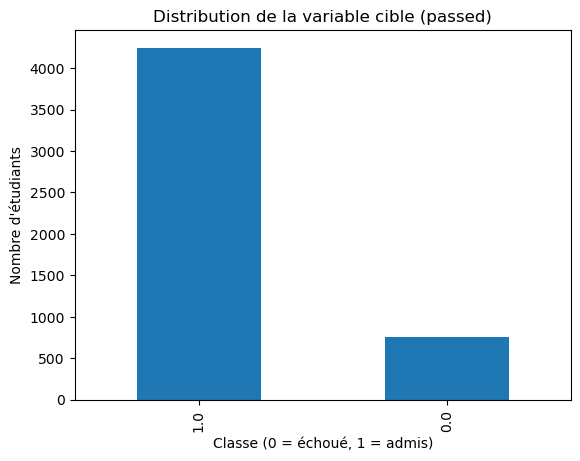

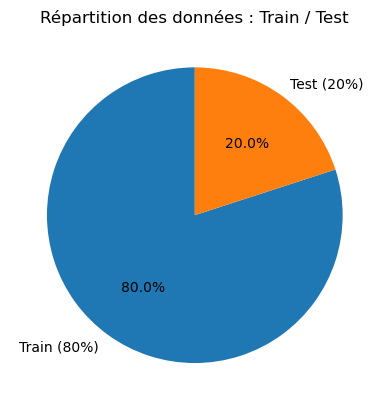

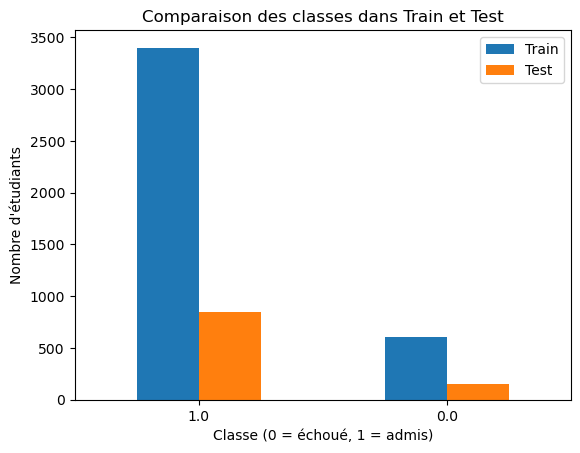

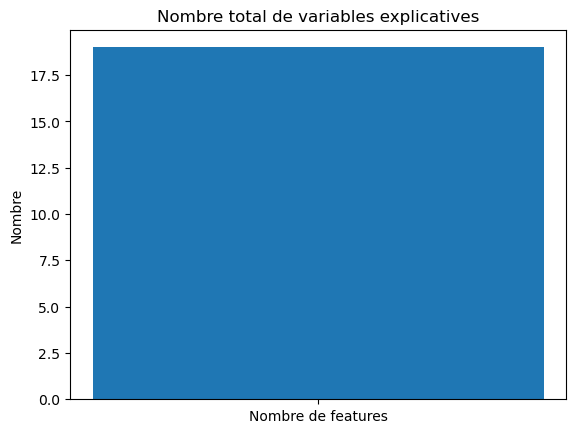

In [4]:
# ============================================
# VISUALISATION – JOUR 6 : DATASET & SPLIT ML
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1️⃣ Chargement du dataset prêt pour le ML
# ------------------------------------------------

df = pd.read_csv("ensp_dataset_ready_for_ML.csv")

TARGET = "passed"  # même target que dans ton script Jour 6

print("✅ Dataset chargé pour visualisation")

# ------------------------------------------------
# 2️⃣ Distribution de la variable cible
# ------------------------------------------------

plt.figure()
df[TARGET].value_counts().plot(kind="bar")
plt.xlabel("Classe (0 = échoué, 1 = admis)")
plt.ylabel("Nombre d'étudiants")
plt.title("Distribution de la variable cible (passed)")
plt.show()

# ------------------------------------------------
# 3️⃣ Répartition Train / Test
# ------------------------------------------------

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")

sizes = [len(X_train), len(X_test)]
labels = ["Train (80%)", "Test (20%)"]

plt.figure()
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Répartition des données : Train / Test")
plt.show()

# ------------------------------------------------
# 4️⃣ Comparaison des classes dans Train et Test
# ------------------------------------------------

y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

train_counts = y_train[TARGET].value_counts()
test_counts = y_test[TARGET].value_counts()

df_classes = pd.DataFrame({
    "Train": train_counts,
    "Test": test_counts
}).fillna(0)

df_classes.plot(kind="bar")
plt.xlabel("Classe (0 = échoué, 1 = admis)")
plt.ylabel("Nombre d'étudiants")
plt.title("Comparaison des classes dans Train et Test")
plt.xticks(rotation=0)
plt.show()

# ------------------------------------------------
# 5️⃣ Nombre de variables (features)
# ------------------------------------------------

plt.figure()
plt.bar(
    ["Nombre de features"],
    [df.drop(columns=['passed','student_id','overall_grade']).shape[1]]
)
plt.ylabel("Nombre")
plt.title("Nombre total de variables explicatives")
plt.show()
